# Theta Embedding Compare

这个 notebook 用来比较两个模型的评估结果：

1. `no_theta_embed_31`：`/home/server/projects/energy_reconstruction/runs/huber_raw_31`
2. `theta_embed_2707`：`/home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_only`

结果文件自动读取自已有评估输出：

- `metrics.json`
- `preds.npz`

并复用当前项目 `src/common/utils.py` 中的统计定义，基于 `preds.npz` 重算并对比三条 `mc-weighted` 曲线：

- resolution
- bias
- logRMS


## 1. 设置路径并准备统计函数

这一格只做环境准备：定位项目根目录、输出目录，并定义与 `src/common/utils.py` 保持一致的加权统计函数。

In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/home/server/projects/energy_reconstruction')
NOTEBOOK_DIR = PROJECT_ROOT / 'notebook'
OUTPUT_DIR = NOTEBOOK_DIR / 'generated' / 'theta_embedding_compare'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

def _weighted_mean(x, w):
    w = np.asarray(w, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    s = np.sum(w)
    if s <= 0:
        return np.nan
    return np.sum(w * x) / s

def _weighted_var(x, w):
    m = _weighted_mean(x, w)
    if not np.isfinite(m):
        return np.nan
    w = np.asarray(w, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    s = np.sum(w)
    if s <= 0:
        return np.nan
    return np.sum(w * (x - m) ** 2) / s

def _weighted_std(x, w):
    v = _weighted_var(x, w)
    return np.sqrt(v) if np.isfinite(v) and v >= 0 else np.nan

def _weighted_rms(x, w):
    w = np.asarray(w, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)
    s = np.sum(w)
    if s <= 0:
        return np.nan
    return np.sqrt(np.sum(w * x ** 2) / s)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUTPUT_DIR   =', OUTPUT_DIR)


PROJECT_ROOT = /home/server/projects/energy_reconstruction
OUTPUT_DIR   = /home/server/projects/energy_reconstruction/notebook/generated/theta_embedding_compare


## 2. 定义模型目录并检查结果文件

这里把两个模型的结果目录明确绑定起来，并自动打印实际读取到的 `metrics.json` 和 `preds.npz` 路径。

In [2]:
MODELS = {
    'no_theta_embed_31': {
        'run_dir': PROJECT_ROOT / 'runs' / 'huber_raw_31',
        'result_dir': PROJECT_ROOT / 'runs' / 'huber_raw_31' / 'fig',
        'color': '#1f77b4',
        'marker': 'o',
    },
    'theta_embed_2707': {
        'run_dir': PROJECT_ROOT / 'runs' / 'theta_embed_2707',
        'result_dir': PROJECT_ROOT / 'runs' / 'theta_embed_2707' / 'fig_eval_only',
        'color': '#d62728',
        'marker': 's',
    },
}

RESULTS = {}
for label, item in MODELS.items():
    metrics_path = item['result_dir'] / 'metrics.json'
    preds_path = item['result_dir'] / 'preds.npz'

    assert item['run_dir'].exists(), f'Missing run dir: {item["run_dir"]}'
    assert item['result_dir'].exists(), f'Missing result dir: {item["result_dir"]}'
    assert metrics_path.exists(), f'Missing metrics file: {metrics_path}'
    assert preds_path.exists(), f'Missing preds file: {preds_path}'

    RESULTS[label] = {
        'run_dir': item['run_dir'],
        'result_dir': item['result_dir'],
        'metrics_path': metrics_path,
        'preds_path': preds_path,
        'color': item['color'],
        'marker': item['marker'],
    }

for label, item in RESULTS.items():
    print(f'{label:20s} -> {item["result_dir"]}')
    print(f'  metrics : {item["metrics_path"]}')
    print(f'  preds   : {item["preds_path"]}')


no_theta_embed_31    -> /home/server/projects/energy_reconstruction/runs/huber_raw_31/fig
  metrics : /home/server/projects/energy_reconstruction/runs/huber_raw_31/fig/metrics.json
  preds   : /home/server/projects/energy_reconstruction/runs/huber_raw_31/fig/preds.npz
theta_embed_2707     -> /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_only
  metrics : /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_only/metrics.json
  preds   : /home/server/projects/energy_reconstruction/runs/theta_embed_2707/fig_eval_only/preds.npz


## 3. 读取 `metrics.json` 和 `preds.npz`

这一步不手工抄数据，直接从已有结果文件自动读取，并打印整体指标作为对照。

In [3]:
loaded = {}
summary_rows = []

for label, item in RESULTS.items():
    with open(item['metrics_path'], 'r', encoding='utf-8') as f:
        metrics = json.load(f)
    preds = np.load(item['preds_path'])

    loaded[label] = {
        'metrics': metrics,
        'logE_true': preds['logE_true'].astype(np.float64),
        'logE_pred': preds['logE_pred'].astype(np.float64),
        'mc_weight': preds['mc_weight'].astype(np.float64),
    }

    summary_rows.append({
        'model': label,
        'n': metrics['n'],
        'r2_log': metrics['r2_log'],
        'w_log_sigma': metrics['w_log_sigma'],
        'w_log_rmse': metrics['w_log_rmse'],
        'w_log_bias': metrics['w_log_bias'],
    })

for row in summary_rows:
    print(row)


{'model': 'no_theta_embed_31', 'n': 424902, 'r2_log': 0.8591945767402649, 'w_log_sigma': 0.21365120611800203, 'w_log_rmse': 0.21496080240954699, 'w_log_bias': -0.023691954931152608}
{'model': 'theta_embed_2707', 'n': 424903, 'r2_log': 0.8727672100067139, 'w_log_sigma': 0.20554902476909273, 'w_log_rmse': 0.20564634647990992, 'w_log_bias': 0.00632598719060695}


## 4. 按当前项目逻辑重算共享 true-energy bins 上的三条曲线

这里沿用 `src/common/utils.py` 的定义：

- `bias = weighted mean(logE_pred - logE_true)`
- `resolution = weighted std(logE_pred)`
- `logRMS = weighted rms(logE_pred - logE_true)`

为了让两条曲线可直接同图比较，这里对两个模型使用相同的 true-energy bin。

In [4]:
def compute_weighted_curves(log_true, log_pred, weights, bin_edges):
    mask = (
        np.isfinite(log_true)
        & np.isfinite(log_pred)
        & np.isfinite(weights)
        & (weights > 0)
    )

    log_true = log_true[mask]
    log_pred = log_pred[mask]
    weights = weights[mask]

    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bias = []
    resolution = []
    log_rms = []

    for i in range(len(bin_edges) - 1):
        m = (log_true >= bin_edges[i]) & (log_true < bin_edges[i + 1])
        if m.sum() > 10:
            residual = log_pred[m] - log_true[m]
            w = weights[m]
            bias.append(float(_weighted_mean(residual, w)))
            resolution.append(float(_weighted_std(log_pred[m], w)))
            log_rms.append(float(_weighted_rms(residual, w)))
        else:
            bias.append(np.nan)
            resolution.append(np.nan)
            log_rms.append(np.nan)

    return {
        'bin_centers': centers,
        'bias': np.asarray(bias, dtype=np.float64),
        'resolution': np.asarray(resolution, dtype=np.float64),
        'log_rms': np.asarray(log_rms, dtype=np.float64),
    }

combined_true = np.concatenate([
    loaded['no_theta_embed_31']['logE_true'][np.isfinite(loaded['no_theta_embed_31']['logE_true'])],
    loaded['theta_embed_2707']['logE_true'][np.isfinite(loaded['theta_embed_2707']['logE_true'])],
])
bin_edges = np.linspace(combined_true.min(), combined_true.max(), 21)

curves = {}
for label, item in loaded.items():
    curves[label] = compute_weighted_curves(
        item['logE_true'],
        item['logE_pred'],
        item['mc_weight'],
        bin_edges,
    )
    valid_bins = np.isfinite(curves[label]['bias']).sum()
    print(f'{label}: valid bins = {valid_bins}')


no_theta_embed_31: valid bins = 20
theta_embed_2707: valid bins = 20


## 5. 定义统一绘图函数

三张图共用同一套颜色、标记和图例风格，输出到 `notebook/generated/theta_embedding_compare/`。

In [5]:
plot_order = ['no_theta_embed_31', 'theta_embed_2707']

def plot_compare(metric_key, ylabel, title, filename, draw_zero=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    for label in plot_order:
        curve = curves[label]
        style = RESULTS[label]
        ax.plot(
            curve['bin_centers'],
            curve[metric_key],
            marker=style['marker'],
            color=style['color'],
            linewidth=2,
            markersize=5,
            label=label,
        )

    if draw_zero:
        ax.axhline(0.0, color='gray', linestyle='--', linewidth=1)

    ax.set_xlabel(r'True Energy $\log_{10}(E/\mathrm{GeV})$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=True, title='Model')
    ax.grid(alpha=0.3)
    fig.tight_layout()

    out_path = OUTPUT_DIR / filename
    fig.savefig(out_path, dpi=200)
    plt.show()
    print('saved:', out_path)
    return out_path


## 6. 画 resolution 对比图

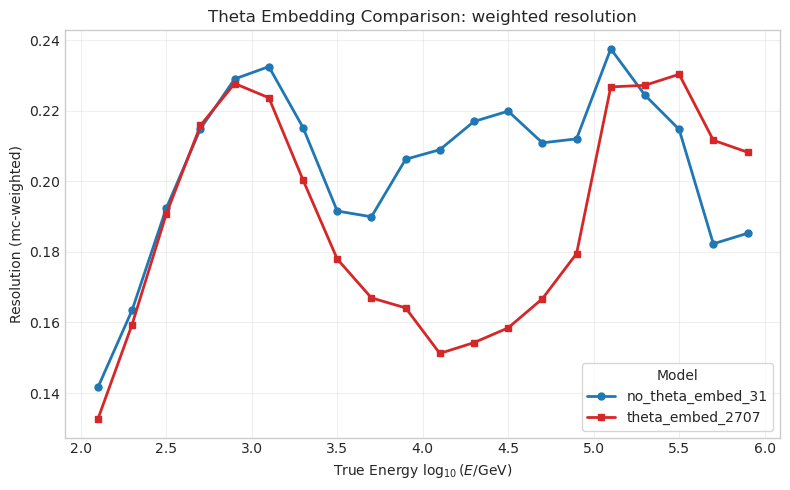

saved: /home/server/projects/energy_reconstruction/notebook/generated/theta_embedding_compare/resolution_compare.png


PosixPath('/home/server/projects/energy_reconstruction/notebook/generated/theta_embedding_compare/resolution_compare.png')

In [6]:
resolution_plot = plot_compare(
    metric_key='resolution',
    ylabel='Resolution (mc-weighted)',
    title='Theta Embedding Comparison: weighted resolution',
    filename='resolution_compare.png',
)
resolution_plot


## 7. 画 bias 对比图

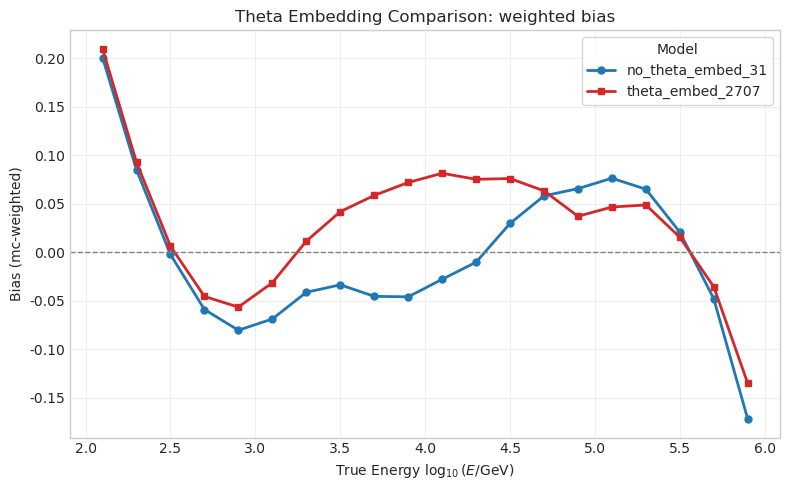

saved: /home/server/projects/energy_reconstruction/notebook/generated/theta_embedding_compare/bias_compare.png


PosixPath('/home/server/projects/energy_reconstruction/notebook/generated/theta_embedding_compare/bias_compare.png')

In [7]:
bias_plot = plot_compare(
    metric_key='bias',
    ylabel='Bias (mc-weighted)',
    title='Theta Embedding Comparison: weighted bias',
    filename='bias_compare.png',
    draw_zero=True,
)
bias_plot


## 8. 画 logRMS 对比图

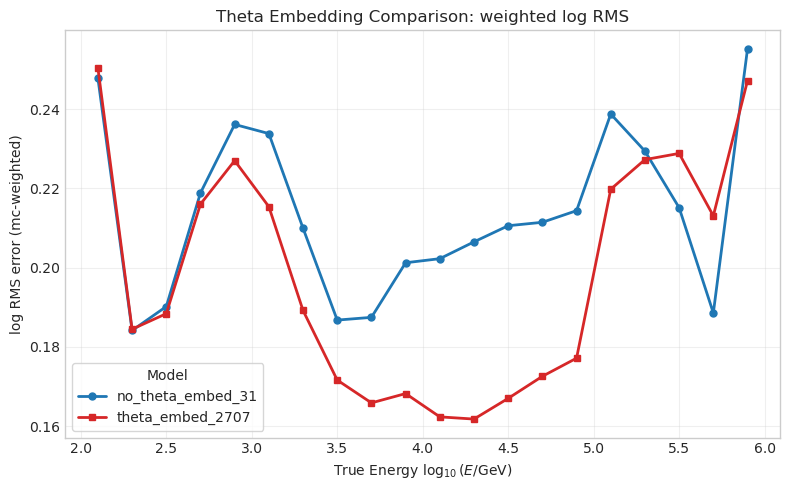

saved: /home/server/projects/energy_reconstruction/notebook/generated/theta_embedding_compare/logRMS_compare.png


PosixPath('/home/server/projects/energy_reconstruction/notebook/generated/theta_embedding_compare/logRMS_compare.png')

In [8]:
logrms_plot = plot_compare(
    metric_key='log_rms',
    ylabel='log RMS error (mc-weighted)',
    title='Theta Embedding Comparison: weighted log RMS',
    filename='logRMS_compare.png',
)
logrms_plot


## 9. 汇总输出文件

最后确认 notebook 生成的三张对比图路径。

In [9]:
generated = [resolution_plot, bias_plot, logrms_plot]
for path in generated:
    print(path)


/home/server/projects/energy_reconstruction/notebook/generated/theta_embedding_compare/resolution_compare.png
/home/server/projects/energy_reconstruction/notebook/generated/theta_embedding_compare/bias_compare.png
/home/server/projects/energy_reconstruction/notebook/generated/theta_embedding_compare/logRMS_compare.png
